In [1]:
import pandas as pd
"""
temperature : 입력값 X(기온 데이터)
sales       : 정답 y(실제 떡볶이 판매량)
"""

df = pd.DataFrame({
    'temperature': [10, 7, 4, 0],   #   temperature 컬럼 (기온)
    'sales': [30, 50, 60, 80]       #   sales 컬럼 (실제 판매량)
})

display(df)

,temperature,sales
0,10,30
1,7,50
2,4,60
3,0,80


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

#   입력값 X와 실제값 y 준비 (TensorFlow2는 보통 2차원 배열을 입력으로 받습니다.)
X = df[['temperature']].values.astype('float32')
y = df[['sales']].values.astype('float32')

#   Dense(1): 입력값을 받아 예측값 1개를 출력하는 선형 층(사실상 a*x + b)
model = keras.Sequential([
    layers.Dense(1, input_shape = (1, ))
])

#   모델 구조 확인
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


In [3]:
"""
compile  : 모델 학습 방법 설정 단계
optimizer: parameter를 수정하는 방법(SGD = 기본적인 Gradient Descent)
   loss  : 모델이 얼마나 틀렸는지 계산하는 기준으로 cost와 같음(mse = 평균제곱오차)
"""
model.compile(
    optimizer = keras.optimizers.SGD(learning_rate = 0.001),
    loss = 'mse'
)

In [4]:
"""
  fit  : compile에서 정한 방식대로 모델을 학습시킴
epochs : 전체 데이털르 몇 번 박복해서 학습할지 정하는 값
         (TensorFlow2는 weight, bias를 랜덤으로 초기화하므로 정답까지 충분히 반복합니다.)
"""

history = model.fit(
    X, y,
    epochs = 10000, verbose = 0
)

print('학습이 끝났습니다.')
print(f"마지막 epoch의 cost: {history.history['loss'][-1]}")

학습이 끝났습니다.
마지막 epoch의 cost: 4.342398643493652


In [5]:
#   학습된 층에서 weight와 bias를 꺼냅니다.
weight, bias = model.layers[0].get_weights()

a_value = weight[0][0]  #   기울기 a에 해당
b_value = bias[0]       #   절편 b에 해당

print(f'학습된 기울기 a: {a_value:.4f}')
print(f' 학습된 절면  b: {b_value:.4f}')

학습된 기울기 a: -4.8253
 학습된 절면  b: 80.2946


In [6]:
#!pip install matplotlib

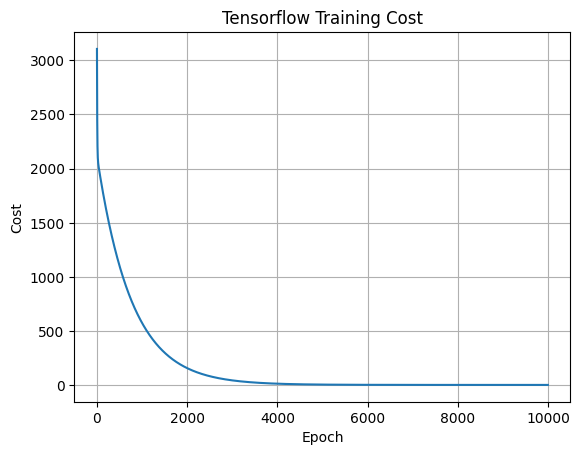

In [7]:
import matplotlib.pyplot as plt

#   history.history['loss']에는 epoch별 cost 값이 저장되어 있음 (TensorFlow2의 Keras API 기본 key 이름은 'loss')
cost_history = history.history['loss']

plt.figure()
plt.plot(cost_history)
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.title('Tensorflow Training Cost')
plt.grid(True)
plt.show()

1/1 [==============================] - 0s 18ms/step


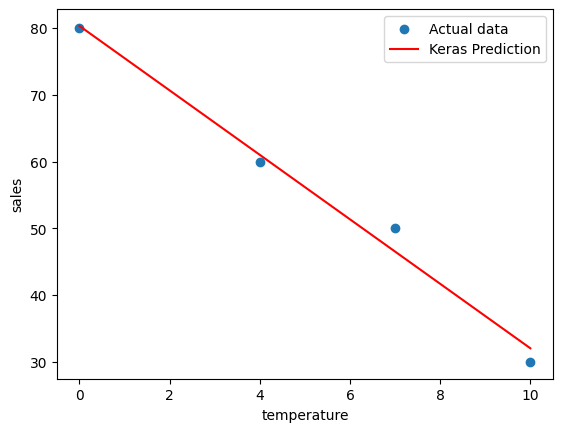

In [9]:
#   model.predict(X): 학습된 모델로 X에 대한 예측값을 계산
pred_y = model.predict(X)

plt.figure()
plt.scatter(X, y, label = 'Actual data')    #   실제 데이터
plt.plot(X, pred_y, color = 'red', label = 'Keras Prediction')  #   예측 직선
plt.xlabel('temperature')
plt.ylabel('sales')
plt.legend()
plt.show()

In [10]:
#   새로운 입력값은 2차원 형태로 넣습니다. (행 1개, 열 1개)
new_temperature = np.array([[5]], dtype = 'float32')
pred_sales = model.predict(new_temperature)

print(f'기온이 5도일 때 예상 판매량: {pred_sales[0][0]:.2f}개')

1/1 [==============================] - 0s 20ms/step
기온이 5도일 때 예상 판매량: 56.17개
